In [1]:
import os
import pandas as pd
import numpy as np
import opendatasets as od
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Excel file into a pandas DataFrame
df = pd.read_excel("../Processed_data.xlsx")

In [3]:
df.head()

,Patient ID,Patient Age,Patient Sex,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,cataract,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,"laser spot,moderate non proliferative retinopathy",0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0
4,4,53,Male,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1


In [4]:
df.describe()

,Patient ID,Patient Age,N,D,G,C,A,H,M,O
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,2218.233143,57.854000,0.463571,0.258000,0.047286,0.044714,0.040000,0.027571,0.038571,0.171429
std,1415.336751,11.723226,0.498707,0.437565,0.212264,0.206691,0.195973,0.163753,0.192585,0.376910
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,876.750000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2372.500000,59.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3247.250000,66.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4784.000000,91.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


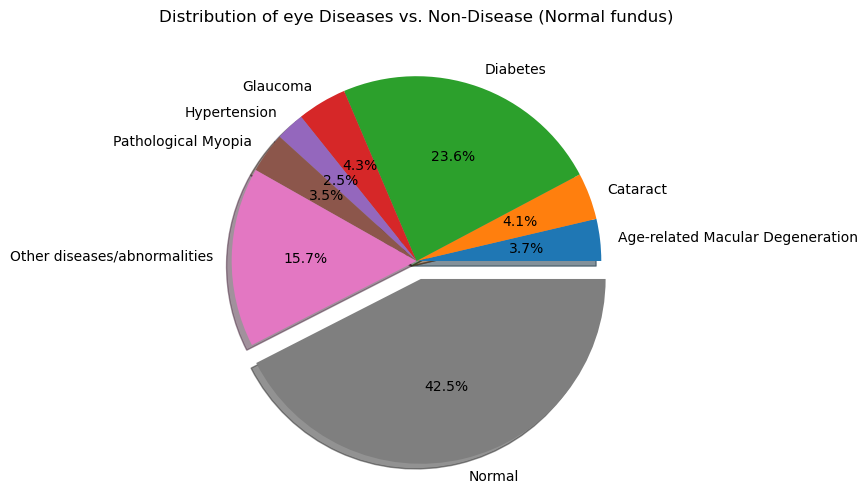

In [8]:
# Full names for diseases
disease_names = {
    "A": "Age-related Macular Degeneration",
    "C": "Cataract",
    "D": "Diabetes",
    "G": "Glaucoma",
    "H": "Hypertension",
    "M": "Pathological Myopia",
    "O": "Other diseases/abnormalities",
    "N": "Normal"
}

# Columns to calculate totals for all diseases except "N"
columns_to_sum = ["A", "C", "D", "G", "H", "M", "O"]

# Calculate the total for each column (excluding "N")
column_totals = df[columns_to_sum].sum()

# Calculate the total for column "N"
total_N = df["N"].sum()

# Create a Series for "N" and other eye diseases
N_series = pd.Series({"N": total_N})

# Concatenate the "N" Series with other disease totals
combined_totals = pd.concat([column_totals, N_series])

# Create a pie chart
labels = [disease_names[label] for label in combined_totals.index]
sizes = combined_totals.values

# Highlight the "N" slice
explode = [0 if label != "Normal" else 0.1 for label in labels]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, explode=explode)
plt.title('Distribution of eye Diseases vs. Non-Disease (Normal fundus)')

plt.show()

In [6]:
# Define health conditions and their full names
diseases = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
disease_names = ['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'Age-related Macular Degeneration', 'Hypertension', 'Pathological Myopia', 'Other']

# Iterate through conditions and calculate value counts for Patient Sex
for diseases, disease_names in zip(diseases, disease_names):
    # Filter the data for the current condition
    disease_data = df[df[diseases] == 1]
    
    # Calculate value counts for Patient Sex
    sex_counts = disease_data['Patient Sex'].value_counts().reset_index()
    sex_counts.columns = ['Patient Sex', f'Frequency ({disease_names})']
    
    # Filter the rows where at least one count exists (ignore rows with all 0s)
    sex_counts = sex_counts[sex_counts[f'Frequency ({disease_names})'] > 0]
    
    # Print the results for the current condition
    print(f"Results for {disease_names}:")
    print(sex_counts)
    print("\n")

Results for Normal:
  Patient Sex  Frequency (Normal)
0        Male                1774
1      Female                1471


Results for Diabetes:
  Patient Sex  Frequency (Diabetes)
0        Male                  1017
1      Female                   789


Results for Glaucoma:
  Patient Sex  Frequency (Glaucoma)
0        Male                   189
1      Female                   142


Results for Cataract:
  Patient Sex  Frequency (Cataract)
0      Female                   179
1        Male                   134


Results for Age-related Macular Degeneration:
  Patient Sex  Frequency (Age-related Macular Degeneration)
0        Male                                           150
1      Female                                           130


Results for Hypertension:
  Patient Sex  Frequency (Hypertension)
0        Male                       118
1      Female                        75


Results for Pathological Myopia:
  Patient Sex  Frequency (Pathological Myopia)
0      Female           

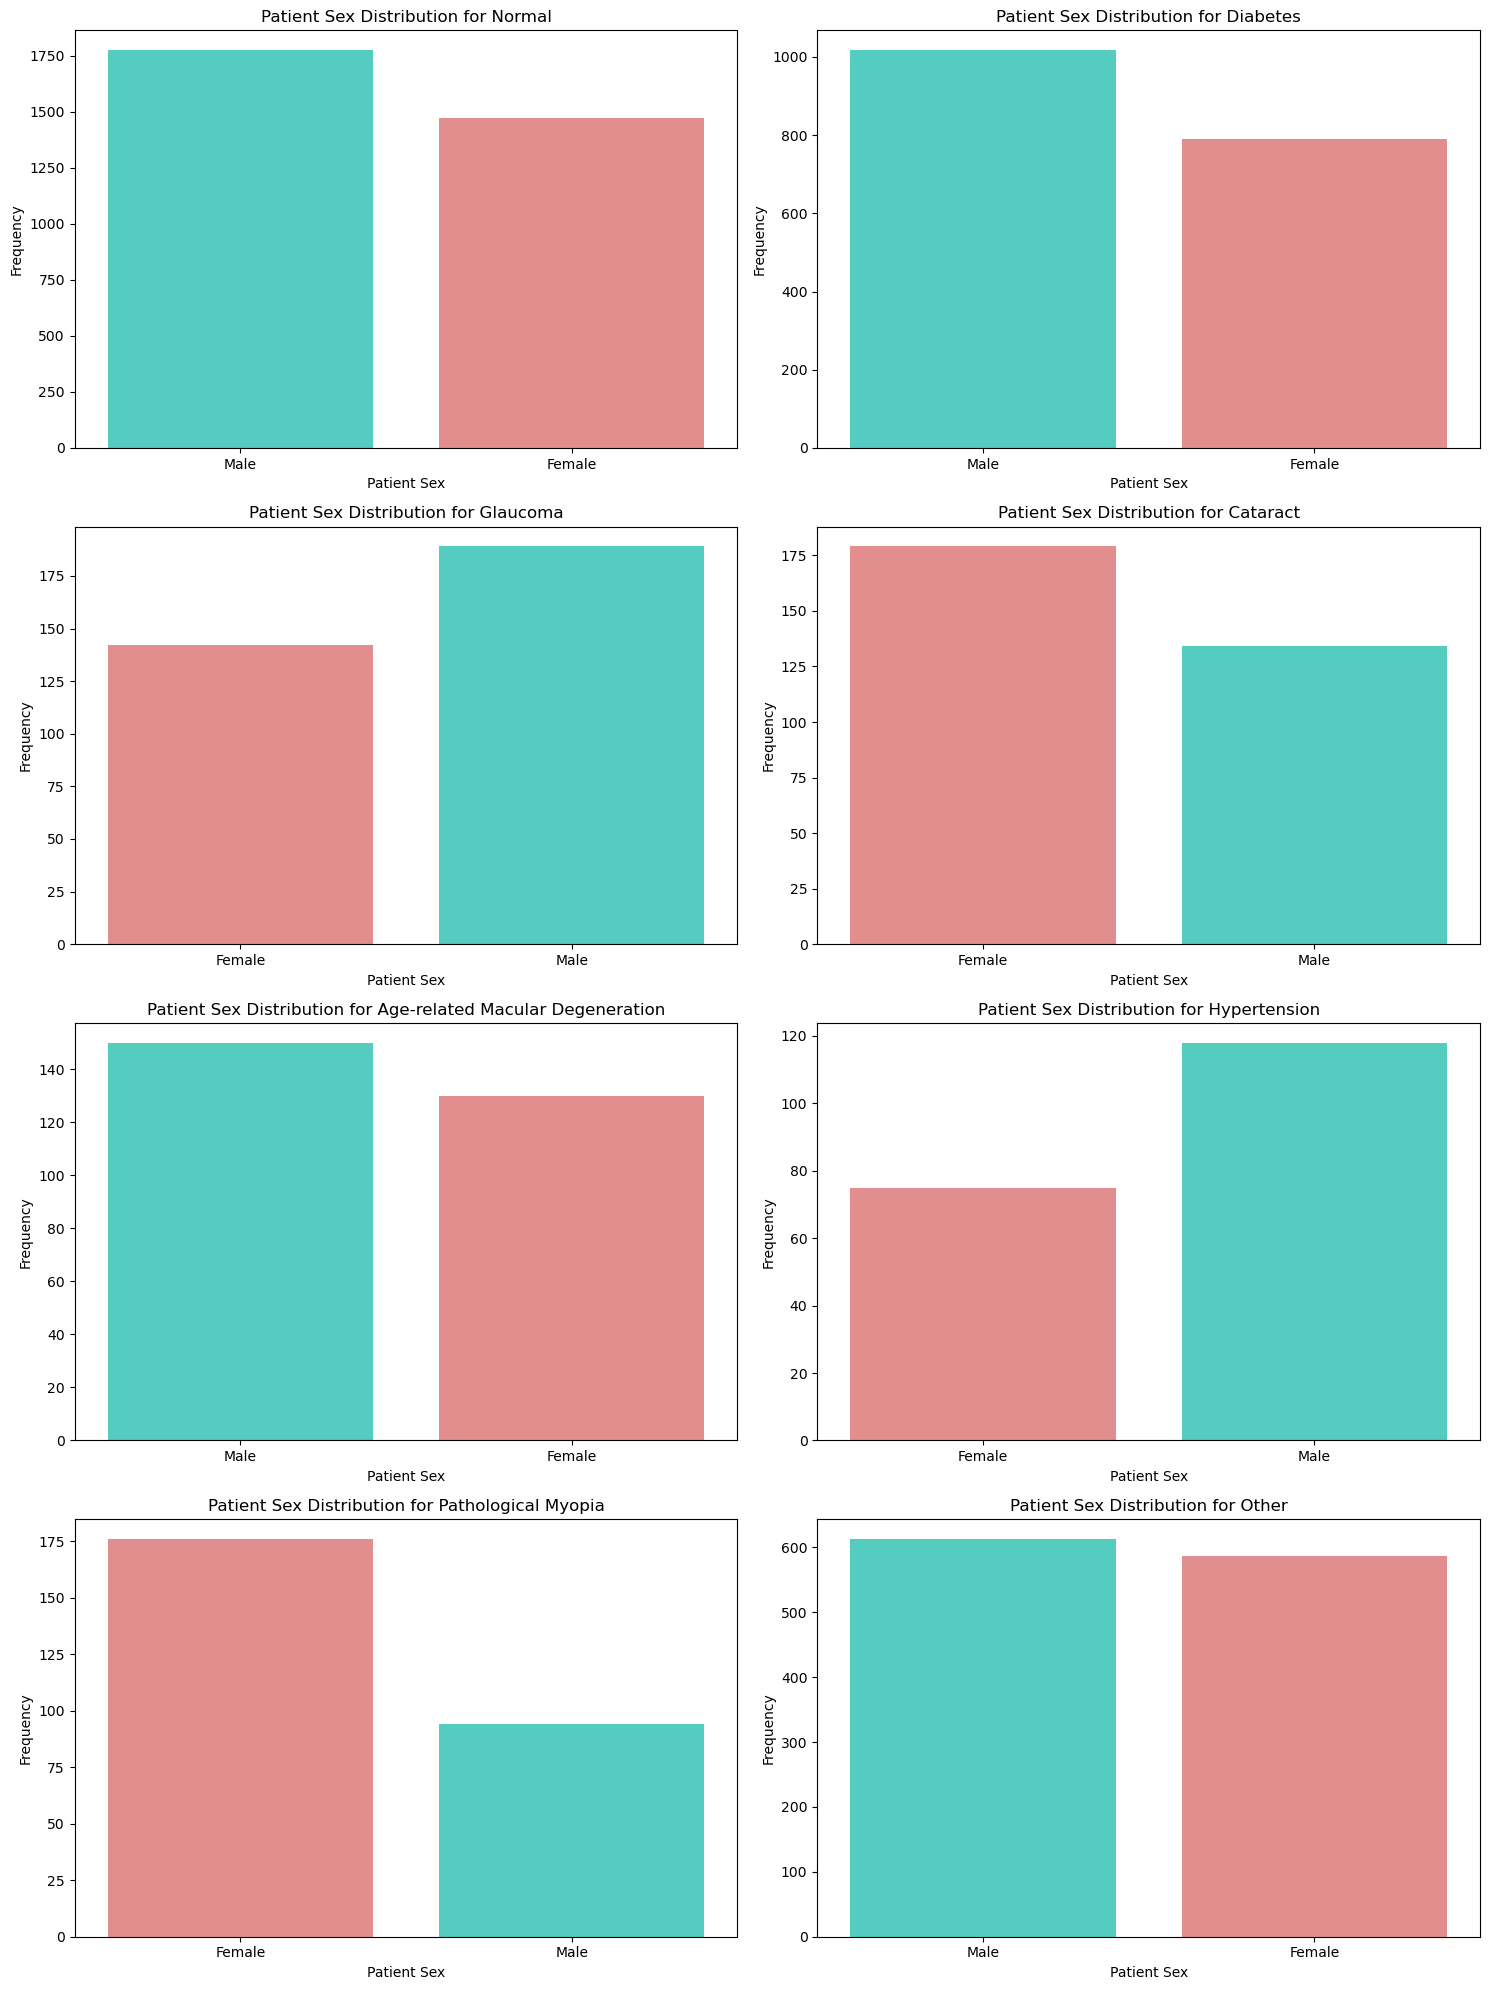

In [7]:
# Define health conditions and their full names
conditions = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
condition_names = ['Normal', 'Diabetes', 'Glaucoma', 'Cataract', 'Age-related Macular Degeneration', 'Hypertension', 'Pathological Myopia', 'Other']

# Define color palette (pink for Female and blue for Male)
custom_palette = {"Female": "lightcoral", "Male": "turquoise"}

# Create a figure with subplots
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

# Iterate through conditions and plot patient sex distribution
for i, condition in enumerate(conditions):
    ax = axes[i // 2, i % 2]  # Select the current subplot
    data = df[df[condition] == 1]  # Filter data for the condition
    
    sns.countplot(data=data, x='Patient Sex', ax=ax, palette=custom_palette)
    
    ax.set_title(f'Patient Sex Distribution for {condition_names[i]}')
    ax.set_xlabel('Patient Sex')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The ratio's between the sex on different diseases slightly changed for some, most notably because of the nature of the dataset before processing. The visuals here paint a more accurate picture of the current state of diseases among sexes. Generally, we can conclude that with the exception of Myopia, other diseases do not have a significant differences between sexes. 

Consequently, it is not worth investigating the impact of sex, to reach any meaningful conclusions that will generalise reasonably outside of this dataset. The visualisation for the data prior to being processed is found in the notebook titled Diseases and Sex Distribution in the same folder.